In [21]:
from pydantic import BaseModel, Field

from qdrant_client import QdrantClient
from qdrant_client.models import Prefetch, Filter, FieldCondition, MatchText, FusionQuery, Document


from langsmith import traceable, get_current_run_tree

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Send, Command

from langchain_core.messages import AIMessage, ToolMessage

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List, Optional, Sequence
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import openai

import random
import ast
import inspect
import instructor
import json

from utils.utils import get_tool_descriptions, format_ai_message
from dotenv import load_dotenv
load_dotenv()

True

### This is about conditionally routing [based on router node]

In [22]:
class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_context: Annotated[List[str], add] = []
    ## This is the addition for router test.
    initial_query: str = ""
    question_relevant: bool = False
    answer: str = ""
    query: str = ""
    k: int = 10

In [23]:
class QueryExpandResponse(BaseModel):
   expanded_query: List[str]

In [24]:
@traceable(
    name="query_expand_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expand_node(state: State) -> dict:

   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to expand it into a list of statements that can be used in contextual search to retrieve relevant products.
- The statements should not overlap in context.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=QueryExpandResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "expanded_query": response.expanded_query
   }

In [25]:
def query_expand_conditional_edges(state: State):

    send_messages = []

    for query in state.expanded_query:
        send_messages.append(
            Send(
                "retrieve_node",
                {
                    "query": query,
                    "k": 10
                }
            )
        )

    return send_messages

In [26]:
@traceable(
    name="embed_query",
    run_type="embedding",
    metadata={"ls_provider": "openai", "ls_model_name": "text-embedding-3-small"}
)
def get_embedding(text, model="text-embedding-3-small"):
    response = openai.embeddings.create(
        input=[text],
        model=model,
    )
    return response.data[0].embedding


@traceable(
    name="retrieve_top_n",
    run_type="retriever"
)
def retrieve_node(state: State) -> dict:

    qdrant_client = QdrantClient(url="http://localhost:6333")

    query_embedding = get_embedding(state["query"])

    results = qdrant_client.query_points(
        collection_name="Amazon-items-collection-01-hybrid-search",
        prefetch=[
            Prefetch(
                query=query_embedding,
                using="text-embedding-3-small",
                limit=20
            ),
            Prefetch(
                query=Document(
                    text=state["query"],
                    model="qdrant/bm25"
                ),
                using="bm25",
                limit=20
            )
        ],
        query=FusionQuery(fusion="rrf"),
        limit=state["k"],
    )

    retrieved_context_ids = []
    retrieved_context = []
    similarity_scores = []
    retrieved_context_ratings = []

    for result in results.points:
        retrieved_context_ids.append(result.payload["parent_asin"])
        retrieved_context.append(result.payload["description"])
        retrieved_context_ratings.append(result.payload["average_rating"])
        similarity_scores.append(result.score)

    formatted_context = ""

    for id, chunk, rating in zip(retrieved_context_ids, retrieved_context, retrieved_context_ratings):
        formatted_context += f"- ID: {id}, rating: {rating}, description: {chunk}\n"

    return {
        "retrieved_context": [formatted_context]
    }

In [27]:
class AggregatorResponse(BaseModel):
    answer: str = Field(description="Answer to the question.")

In [28]:
@traceable(
    name="aggregator_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

   preprocessed_context = "\n".join(state.retrieved_context)

   prompt_template =  """You are a shopping assistant that can answer questions about the products in stock.

You will be given a question and a list of context.

Instructions:
- You need to answer the question based on the provided context only.
- Never use word context and refer to it as the available products.
- The answer to the question should contain detailed information about the product and returned with detailed specification in bullet points.

Context:
{{ preprocessed_context }}

Question:
{{ question }}
"""

   template = Template(prompt_template)

   prompt = template.render(
      preprocessed_context=preprocessed_context,
      question=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=AggregatorResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "answer": response.answer
   }

### User Intent Query Node

In [29]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str

In [30]:
@traceable(
    name="agent_node",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def intent_router_node(state: State):

   prompt_template =  """You are part of a shopping assistant that can answer questions about products in stock.

Instructions:
- You will be given a question and you need to clasify it into relevant or not relevant.
- If the question is not relevant, return False in field "question_relevant" and set "answer" to explanation why it is not relevant.
- If the question is relevant, return True in field "question_relevant" and set "answer" to "".
- You should only answer questions about the products in stock. If the question is not about the products in stock, you should ask for clarification.

<Question>
{{ query }}
</Question>
"""

   template = Template(prompt_template)

   prompt = template.render(
      query=state.initial_query
   )

   client = instructor.from_openai(OpenAI())

   response, raw_response = client.chat.completions.create_with_completion(
        model="gpt-4.1-mini",
        response_model=IntentRouterResponse,
        messages=[{"role": "system", "content": prompt}],
        temperature=0.5,
   )

   return {
      "question_relevant": response.question_relevant,
      "answer": response.answer
      }

In [31]:
def intent_router_conditional_edges(state: State):

    if state.question_relevant:
        return "query_expand_node"
    else:
        return "end"

In [32]:
workflow = StateGraph(State)

workflow.add_node("query_expand_node", query_expand_node)
workflow.add_node("retrieve_node", retrieve_node)
workflow.add_node("aggregator_node", aggregator_node)
## Add intent router node
workflow.add_node("intent_router_node", intent_router_node)

workflow.add_edge(START, "intent_router_node")
workflow.add_conditional_edges("query_expand_node", query_expand_conditional_edges)
## Connect intent router node to query expand node or END based on condition in intent router node
workflow.add_conditional_edges(
    "intent_router_node",
    intent_router_conditional_edges,
    {
        "query_expand_node": "query_expand_node",
        "end": END
    }
)

workflow.add_edge("retrieve_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()

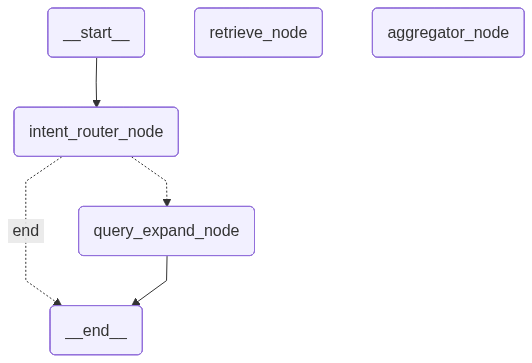

In [33]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [34]:
### This is about relevancy yes

initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me a laptop for my wife and a waterproof speaker for our party next week?"
}
result = graph.invoke(initial_state)

In [35]:
print(result["answer"])

You can find suitable products for your needs in the available products:

1. Tablet for your kid:
- ROWT Tablet for Kids 10 inch
  - 10.1-inch HD 1280x800 IPS touchscreen
  - Android 11 OS
  - 2GB RAM, 32GB ROM
  - 6000mAh battery
  - Kid-proof case with built-in stand
  - Parental controls including password protection, content filter, and one-button lock screen
  - Access to Google Play for apps like Gmail, Disney+, YouTube

2. Watch for you:
- Smart Watch for Men Women (Make/Answer Call) (Black)
  - Bluetooth call and text reminder
  - Fitness tracker with heart rate and sleep monitoring
  - Waterproof design
  - Long battery life (up to a week)
  - Compatible with iOS 9.0/Android 5.0 or later

3. Laptop for your wife:
- Lenovo Newest Ideapad 15.6" Laptop
  - 15.6 inch HD IPS display (1366 x 768)
  - AMD Athlon Silver 3050U dual-core processor
  - 4GB RAM, 128GB PCIe SSD
  - WiFi 6 and Bluetooth 5.0
  - Windows 11 Home in S Mode
  - Lightweight (3.3 pounds)

4. Waterproof speaker fo

In [36]:
initial_state = {
    "initial_query": "Can I get a tablet for my kid, a watch for me a laptop for my wife and dishwasher tablet for my dishwasher?"
}
result = graph.invoke(initial_state)

In [37]:
print(result["answer"])

You can get the following from the available products:

Tablet for your kid:
- ROWT Tablet for Kids 10 inch Kids Tablet
  - 10.1 inch HD 1280x800 IPS touchscreen
  - Android 11 OS
  - 2GB RAM, 32GB ROM storage
  - 6000mAh battery
  - Kid-proof case with built-in stand
  - Parental controls including password protection, content filter, and one-button lock screen
  - Access to Google Play for apps like Gmail, Disney+, YouTube
  - Creative educational content such as drawing, games, eBooks, learning videos

Watch for you:
- BJNAAL Smart Watch for Android Phones iOS Compatible
  - 1.69 inch large screen
  - Fitness tracker with heart rate, blood pressure, sleep monitor
  - Supports 25 sports modes
  - Bluetooth smart watch compatible with iOS 9.0 & Android 4.4+
  - IP68 waterproof
  - Long battery life with 7 days working time, 30 days standby

Laptop for your wife:
- Lenovo Newest Ideapad 15.6" Laptop
  - 15.6 inch HD IPS display (1366 x 768)
  - AMD Athlon Silver 3050U dual-core process

In [38]:
initial_state = {
    "initial_query": "Whats the weather today?"
}
result = graph.invoke(initial_state)

In [39]:
print(result["answer"])

The question about the weather today is not relevant to the products in stock. Please ask about products or shopping-related inquiries.
